# Heston model — pricing, implied-vol surface, Greeks & calibration

This notebook drives the C++ `heston` engine through its `pybind11` bindings.
It shows the three things the library is built to do:

1. Build a **Heston implied-volatility surface** (Fourier pricing + BS inversion).
2. Read off **semi-analytic Greeks** (delta / gamma) across strikes.
3. **Calibrate** the five Heston parameters back from a set of option prices.

Build the module first with `-DHESTON_BUILD_PYTHON=ON` (see the README).

In [1]:
import sys
import pathlib

import numpy as np
import matplotlib
try:
    get_ipython()  # noqa: F821  -- only defined inside a Jupyter/IPython kernel
except NameError:
    matplotlib.use("Agg")  # plain script: render headless and just save PNGs
import matplotlib.pyplot as plt

# Locate the compiled `heston` extension (built into build/bindings).
_here = pathlib.Path(globals().get("__file__", pathlib.Path.cwd() / "x")).resolve().parent
_candidates = [_here / ".." / "build" / "bindings", pathlib.Path.cwd() / "build" / "bindings"]
for _c in _candidates:
    if _c.exists() and (list(_c.glob("heston*.pyd")) or list(_c.glob("heston*.so"))):
        sys.path.insert(0, str(_c.resolve()))
        break

import heston as h  # noqa: E402

IMG = _here / "img"
IMG.mkdir(exist_ok=True)

## Market & model
A spot of 100, 3% rate, 1% dividend yield, and a Heston parameter set with a
pronounced negative spot/vol correlation (which produces the equity skew).

In [2]:
mkt = h.Market(s0=100.0, r=0.03, q=0.01)
params = h.HestonParams(v0=0.04, kappa=1.5, theta=0.05, sigma=0.6, rho=-0.7)
fp = h.HestonFourierPricer(alpha=1.5, u_max=250.0, n_intervals_even=12000)

atm = h.VanillaOption(h.OptionType.Call, 100.0, 1.0)
print("ATM 1y call price :", round(fp.price(atm, mkt, params), 6))
print("Feller satisfied  :", params.satisfies_feller())

ATM 1y call price : 8.362943
Feller satisfied  : False


## 1. Implied-volatility surface
For each (strike, maturity) we price a call with the Fourier engine and invert
the Black–Scholes formula to recover the implied vol. The downward slope in
strike is the volatility skew induced by `rho < 0`.

saved C:/Users/SCA/Desktop/claude nonsense/code/heston_model_pricing_and_calibration/notebooks/img/iv_surface.png


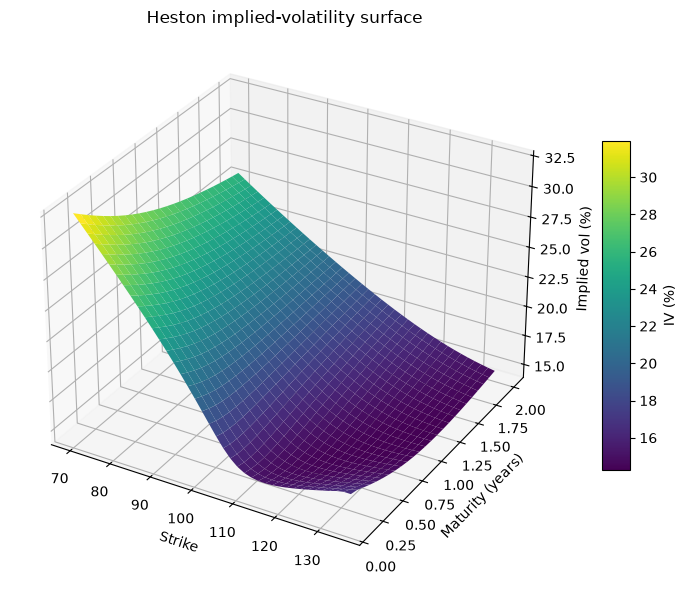

In [3]:
strikes = np.linspace(70.0, 135.0, 40)
maturities = np.linspace(0.1, 2.0, 25)
IV = np.full((maturities.size, strikes.size), np.nan)

for i, T in enumerate(maturities):
    for j, K in enumerate(strikes):
        opt = h.VanillaOption(h.OptionType.Call, float(K), float(T))
        try:
            px = fp.price(opt, mkt, params)
            IV[i, j] = h.implied_vol(opt, mkt, px)
        except Exception:
            pass  # leave NaN where inversion is ill-posed (deep wings)

Kg, Tg = np.meshgrid(strikes, maturities)
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Kg, Tg, IV * 100.0, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (years)")
ax.set_zlabel("Implied vol (%)")
ax.set_title("Heston implied-volatility surface")
fig.colorbar(surf, shrink=0.6, aspect=12, label="IV (%)")
fig.tight_layout()
fig.savefig(IMG / "iv_surface.png", dpi=130)
print("saved", IMG / "iv_surface.png")
plt.show()

## 2. Semi-analytic Greeks across strikes (T = 1y)
Delta and gamma come from differentiating the Carr–Madan integral under the
integral sign — a single quadrature pass returns price, delta, gamma and rho.

saved C:/Users/SCA/Desktop/claude nonsense/code/heston_model_pricing_and_calibration/notebooks/img/greeks.png


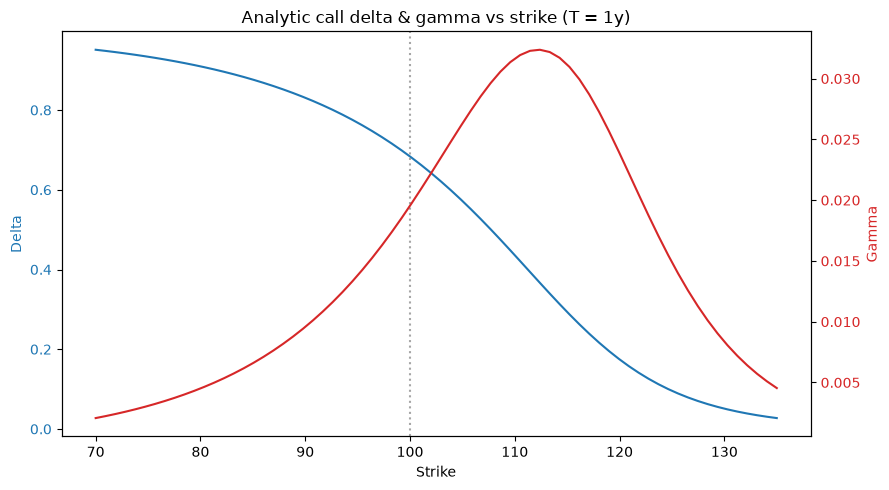

In [4]:
Ks = np.linspace(70.0, 135.0, 70)
delta = np.empty_like(Ks)
gamma = np.empty_like(Ks)
for idx, K in enumerate(Ks):
    opt = h.VanillaOption(h.OptionType.Call, float(K), 1.0)
    g = fp.analytic_greeks(opt, mkt, params)
    delta[idx] = g.delta
    gamma[idx] = g.gamma

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(Ks, delta, color="C0", label="delta")
ax1.set_xlabel("Strike")
ax1.set_ylabel("Delta", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.axvline(mkt.s0, ls=":", color="grey", alpha=0.7)
ax2 = ax1.twinx()
ax2.plot(Ks, gamma, color="C3", label="gamma")
ax2.set_ylabel("Gamma", color="C3")
ax2.tick_params(axis="y", labelcolor="C3")
ax1.set_title("Analytic call delta & gamma vs strike (T = 1y)")
fig.tight_layout()
fig.savefig(IMG / "greeks.png", dpi=130)
print("saved", IMG / "greeks.png")
plt.show()

## 3. Calibration round-trip
We generate synthetic call prices from a *true* parameter set, then calibrate
(CMA-ES) starting from a deliberately wrong guess and check that we recover the
smile. The table reports the recovered parameters and the fit loss.

  param       true    recovered
     v0     0.0400       0.0404
  kappa     1.5000       1.6113
  theta     0.0500       0.0493
  sigma     0.6000       0.6208
    rho    -0.7000      -0.7008
calibration loss = 3.464e-04   iters = 300


saved C:/Users/SCA/Desktop/claude nonsense/code/heston_model_pricing_and_calibration/notebooks/img/calibration.png


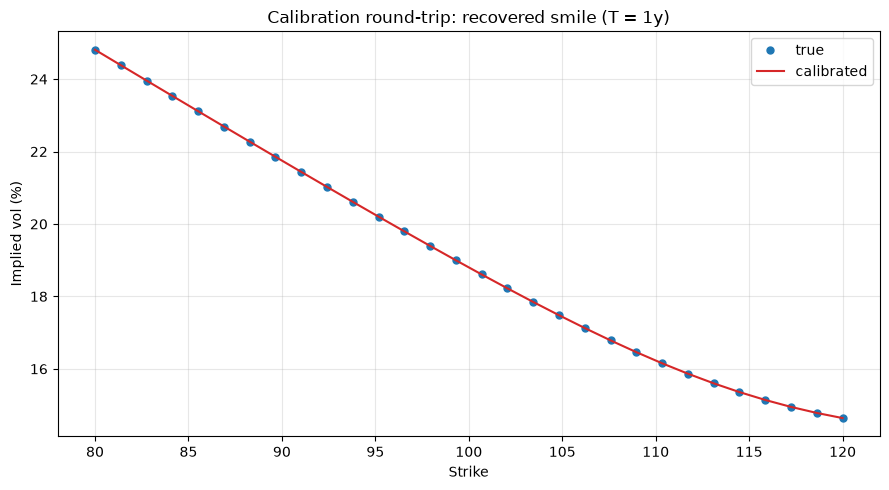

In [5]:
true = params
quote_strikes = [80.0, 90.0, 100.0, 110.0, 120.0]
quote_mats = [0.5, 1.0, 1.5]
quotes = []
for T in quote_mats:
    for K in quote_strikes:
        opt = h.VanillaOption(h.OptionType.Call, K, T)
        quotes.append(h.PriceQuote(opt, fp.price(opt, mkt, true), 1.0))

guess = h.HestonParams(v0=0.05, kappa=1.0, theta=0.06, sigma=0.4, rho=-0.3)
report = h.calibrate_heston_to_prices_cmaes(quotes, mkt, guess)
rec = report.params

print(f"{'param':>7} {'true':>10} {'recovered':>12}")
for name in ("v0", "kappa", "theta", "sigma", "rho"):
    print(f"{name:>7} {getattr(true, name):>10.4f} {getattr(rec, name):>12.4f}")
print(f"calibration loss = {report.loss:.3e}   iters = {report.iters}")

# Compare true vs recovered smile at T = 1y.
smile_K = np.linspace(80.0, 120.0, 30)
iv_true = np.empty_like(smile_K)
iv_rec = np.empty_like(smile_K)
for idx, K in enumerate(smile_K):
    opt = h.VanillaOption(h.OptionType.Call, float(K), 1.0)
    iv_true[idx] = h.implied_vol(opt, mkt, fp.price(opt, mkt, true))
    iv_rec[idx] = h.implied_vol(opt, mkt, fp.price(opt, mkt, rec))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(smile_K, iv_true * 100.0, "o", color="C0", label="true", markersize=5)
ax.plot(smile_K, iv_rec * 100.0, "-", color="C3", label="calibrated")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied vol (%)")
ax.set_title("Calibration round-trip: recovered smile (T = 1y)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(IMG / "calibration.png", dpi=130)
print("saved", IMG / "calibration.png")
plt.show()